# Analyse topologique des réseaux SUMO
Comparaison de réseaux à partir de signatures de carrefours, de patchs et d’agrégations multi-échelles.

In [1]:
import os
import glob
import pathlib
import sumolib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# plotly is optional; moved here so interactive cell can use it if available
try:
    import plotly.graph_objects as go
except Exception:
    go = None
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy.spatial import distance_matrix
from scipy.spatial.distance import euclidean
# Option pour que le notebook affiche toutes les colonnes de nos tableaux sans les masquer
pd.set_option('display.max_columns', None)


def pretty_network_name(net_file_path):
    """Renvoie un nom lisible pour un réseau SUMO quand on peut l'inférer."""
    path = pathlib.Path(net_file_path).resolve()

    def readme_title(directory):
        for readme_name in ("README.md", "Readme.md", "readme.md"):
            readme_path = directory / readme_name
            if not readme_path.is_file():
                continue
            try:
                content = readme_path.read_text(encoding="utf-8", errors="ignore")
            except Exception:
                continue
            for line in content.splitlines():
                stripped = line.strip()
                if stripped.startswith("#"):
                    title = stripped.lstrip("#").strip()
                    if title:
                        return title
        return None

    search_dirs = [path.parent, *list(path.parents)[1:4]]
    for directory in search_dirs:
        title = readme_title(directory)
        if title:
            return title

    candidate = path.parent.name if path.parent.name else path.stem
    if candidate.lower() == "scenario" and path.parent.parent.name:
        candidate = path.parent.parent.name

    candidate = candidate.replace("_", " ").replace("-", " ").strip()
    return candidate.title() if candidate else path.stem


In [2]:
def extract_intersection_features(net_file_path):
    """Extrait les variables topologiques d'un réseau SUMO."""
    chemin_securise = pathlib.Path(net_file_path).resolve().as_uri()
    net = sumolib.net.readNet(chemin_securise, withPrograms=True)
    
    features = []
    index_ids = []
    
    # LA CORRECTION EST ICI :
    # On récupère tous les programmes de feux du réseau dans un dictionnaire
    tls_list = net.getTrafficLights()
    tls_dict = {tls.getID(): tls for tls in tls_list}
    
    for node in net.getNodes():
        if not node.getType().startswith('traffic_light'):
            continue
            
        node_id = node.getID()
        edges_in = node.getIncoming()
        edges_out = node.getOutgoing()
        
        if not edges_in or not edges_out:
            continue
            
        num_incoming_lanes = sum(len(edge.getLanes()) for edge in edges_in)
        connections = node.getConnections()
        
        lane_connection_counts = {}
        for conn in connections:
            from_lane = conn.getFromLane().getID()
            lane_connection_counts[from_lane] = lane_connection_counts.get(from_lane, 0) + 1
        
        dedicated_lanes = sum(1 for count in lane_connection_counts.values() if count == 1)
        prop_dedicated_lanes = dedicated_lanes / num_incoming_lanes if num_incoming_lanes > 0 else 0
        
        # Nouveau calcul du nombre de phases
        num_phases = 0
        if node_id in tls_dict:
            tls = tls_dict[node_id]
            programs = tls.getPrograms()
            if programs:
                first_program = list(programs.values())[0]
                num_phases = len(first_program.getPhases())
                
        row = {
            'branches': len(edges_in),
            'voies_entrantes': num_incoming_lanes,
            'voies_sortantes': sum(len(edge.getLanes()) for edge in edges_out),
            'prop_voies_dediees': prop_dedicated_lanes,
            'nb_phases': num_phases,
            'longueur_moy_entree': np.mean([edge.getLength() for edge in edges_in])
        }
        
        features.append(row)
        index_ids.append(node_id)
        
    return pd.DataFrame(features, index=index_ids)

## Préparation des données
Import des bibliothèques et définition des fonctions d’extraction des caractéristiques des réseaux.

In [3]:
# Les deux chemins de base possibles selon l'endroit où le kernel tourne
dossier_depuis_notebooks = "../networks/"
dossier_depuis_racine = "networks/"

# Patterns à rechercher (inclut les dossiers 'scenario' et fichiers LuST spécifiques)
patterns = ["**/*.net.xml", "**/scenario/*.net.xml", "**/lust*.net.xml"]

# Recherche en combinant plusieurs racines et motifs
fichiers_net = []
for root in [dossier_depuis_notebooks, dossier_depuis_racine]:
    for pat in patterns:
        fichiers_net.extend(glob.glob(os.path.join(root, pat), recursive=True))

# Cherche explicitement les variantes de nom de dossier LuST (master / underscore / dash)
for base in ['LuSTScenario-master', 'LuSTScenario_master', 'LuSTScenario']:
    lust_pattern = os.path.join('networks', base, 'scenario', '*.net.xml')
    fichiers_net.extend(glob.glob(lust_pattern))

# Dédupliquer et trier
fichiers_net = sorted(set(fichiers_net))

if fichiers_net:
    print(f"Génial ! {len(fichiers_net)} réseau(x) trouvé(s) :\n")
    for i, fichier in enumerate(fichiers_net):
        print(f"[{i}] {fichier}")
        
    # On sélectionne automatiquement le premier fichier de la liste
    chemin_scenario = fichiers_net[0]
    print(f"\n--- Analyse du réseau : {os.path.basename(chemin_scenario)} ---")
    
    # Lancement de l'extraction
    df_topologie = extract_intersection_features(chemin_scenario)

    print(f"Extraction réussie : {len(df_topologie)} carrefours analysés.")
    print("Aperçu des données brutes :")
    display(df_topologie.head())
else:
    print("Erreur : Aucun fichier .net.xml n'a été trouvé. Vérifiez que les dossiers contiennent bien les fichiers de simulation.")


Génial ! 8 réseau(x) trouvé(s) :

[0] ../networks\LuSTScenario-master\scenario\lust.net.xml
[1] ../networks\X-Light\scenarios\large_grid2\exp.net.xml
[2] ../networks\X-Light\scenarios\nanshan\osm.net.xml
[3] ../networks\X-Light\scenarios\resco_envs\arterial4x4\arterial4x4.net.xml
[4] ../networks\X-Light\scenarios\resco_envs\cologne8\cologne8.net.xml
[5] ../networks\X-Light\scenarios\resco_envs\grid4x4\grid4x4.net.xml
[6] ../networks\X-Light\scenarios\resco_envs\ingolstadt21\ingolstadt21.net.xml
[7] ../networks\X-Light\scenarios\sumo_fenglin_base_road\fenglin_y2z_t.net.xml

--- Analyse du réseau : lust.net.xml ---
Extraction réussie : 203 carrefours analysés.
Aperçu des données brutes :


,branches,voies_entrantes,voies_sortantes,prop_voies_dediees,nb_phases,longueur_moy_entree
-11042,4,7,7,0.142857,8,305.360000
-27336,4,10,10,0.500000,8,218.297500
-4214,5,14,11,0.642857,10,95.958000
-10820,3,7,7,0.571429,6,192.833333
-16136,3,7,6,0.857143,4,61.596667


## Exploration des scénarios
Recherche des fichiers de réseaux disponibles et première extraction de topologie.

In [4]:
# --- CELLULE : Tableau récapitulatif des métriques réseau ---

def analyze_net_summary(netfile):
    chemin_securise = pathlib.Path(netfile).resolve().as_uri()
    net = sumolib.net.readNet(chemin_securise, withPrograms=True)
    edges = [e for e in net.getEdges() if not (getattr(e,'getID',lambda:'')().startswith(':'))]
    nb_liens = len(edges)
    lanes_per_branch = []
    branches_per_junction = []
    phases_counts = []
    lengths = []
    tls_list = net.getTrafficLights()
    tls_dict = {tls.getID(): tls for tls in tls_list}
    nb_junctions = len(tls_dict)

    for edge in edges:
        lanes = edge.getLanes()
        lanes_per_branch.append(len(lanes) if lanes else 0)
        try:
            lengths.append(edge.getLength())
        except Exception:
            pass

    for node in net.getNodes():
        node_id = node.getID()
        # compter seulement les noeuds qui ont des feux ET qui sont de type traffic_light (ou variante)
        if not node.getType().startswith('traffic_light'):
            continue
        if node_id not in tls_dict:
            continue
        edges_in = node.getIncoming()
        edges_out = node.getOutgoing()
        # aussi vérifier qu'il y a bien des entrées et sorties
        if edges_in and edges_out:
            branches_per_junction.append(len(edges_in))
            # compter les phases
            tls = tls_dict[node_id]
            programs = tls.getPrograms()
            if programs:
                first_prog = list(programs.values())[0]
                num_ph = len(first_prog.getPhases())
                phases_counts.append(num_ph)

    return {
        'network_name': os.path.basename(os.path.dirname(netfile)),
        'n_junctions': nb_junctions,
        'n_links': nb_liens,
        'avg_lanes_per_branch': round(sum(lanes_per_branch)/len(lanes_per_branch),2) if lanes_per_branch else 0,
        'avg_branches_per_junction': round(sum(branches_per_junction)/len(branches_per_junction),2) if branches_per_junction else 0,
        'avg_phases_per_junction': round(sum(phases_counts)/len(phases_counts),2) if phases_counts else 0,
        'avg_link_length': round(sum(lengths)/len(lengths),2) if lengths else 0,
    }

# Cherche tous les .net.xml (utilise la variable existante si disponible)
net_files_local = fichiers_net if 'fichiers_net' in globals() else glob.glob(os.path.join('networks','**','*.net.xml'), recursive=True)
summary = []
for f in sorted(net_files_local):
    try:
        summary.append(analyze_net_summary(f))
    except Exception as e:
        summary.append({'network_name': os.path.basename(os.path.dirname(f)),'n_junctions':None,'n_links':None,'avg_lanes_per_branch':None,'avg_branches_per_junction':None,'avg_phases_per_junction':None,'avg_link_length':None})

df_summary = pd.DataFrame(summary)
cols = ['network_name','n_junctions','n_links','avg_lanes_per_branch','avg_branches_per_junction','avg_phases_per_junction','avg_link_length']
display(df_summary[cols].sort_values('network_name').reset_index(drop=True))

,network_name,n_junctions,n_links,avg_lanes_per_branch,avg_branches_per_junction,avg_phases_per_junction,avg_link_length
0,arterial4x4,16,80,1.50,4.00,10.00,137.68
1,cologne8,8,149,1.05,3.38,6.25,98.91
2,grid4x4,16,80,3.00,4.00,16.00,278.24
3,ingolstadt21,21,853,2.25,3.33,6.53,82.97
4,large_grid2,25,120,3.00,4.00,16.00,135.67
5,nanshan,55,2072,1.89,3.67,4.17,181.99
6,scenario,201,5779,1.49,3.25,6.45,160.80
7,sumo_fenglin_base_road,7,106,2.42,3.71,6.86,213.07


## Synthèse réseau
Calcul des métriques globales de chaque réseau pour comparer leur structure générale.

In [5]:
# --- SECTION 0.2 : Comparaison inter-réseaux (fonction sur 2 carrefours) ---


def extract_network_features(net_file_path):
    """Extrait les variables globales d'un réseau SUMO."""
    chemin_securise = pathlib.Path(net_file_path).resolve().as_uri()
    net = sumolib.net.readNet(chemin_securise, withPrograms=True)

    def is_internal_edge(edge):
        edge_id = edge.getID()
        if edge_id.startswith(':'):
            return True

        get_function = getattr(edge, 'getFunction', None)
        if callable(get_function):
            try:
                return get_function() == 'internal'
            except TypeError:
                return False

        return False

    edges = [edge for edge in net.getEdges() if not is_internal_edge(edge)]
    tls_list = net.getTrafficLights()
    tls_dict = {tls.getID(): tls for tls in tls_list}

    return {
        'n_junctions': len(tls_dict),
        'n_links': len(edges),
        'avg_link_length': np.mean([edge.getLength() for edge in edges]) if edges else 0,
    }


def enrich_carrefour_features(net_file_path):
    """Ajoute les variables globales du réseau à chaque carrefour."""
    df_carrefours = extract_intersection_features(net_file_path).copy()
    if df_carrefours.empty:
        return df_carrefours

    network_features = extract_network_features(net_file_path)
    for feature_name, feature_value in network_features.items():
        df_carrefours[feature_name] = feature_value

    return df_carrefours


def comparer_deux_carrefours(carrefour_1, carrefour_2, afficher=True):
    """
    Compare 2 carrefours et renvoie les mêmes sorties que la cellule initiale.
    Entrées :
        carrefour_1 = (chemin_reseau_1, id_carrefour_reseau_1)
        carrefour_2 = (chemin_reseau_2, id_carrefour_reseau_2)
        afficher=True pour reproduire exactement les affichages de la cellule.
    """
    chemin_reseau_1, id_carrefour_reseau_1 = carrefour_1
    chemin_reseau_2, id_carrefour_reseau_2 = carrefour_2

    df_reseau_1 = extract_intersection_features(chemin_reseau_1)
    df_reseau_2 = extract_intersection_features(chemin_reseau_2)

    network_features_1 = extract_network_features(chemin_reseau_1)
    network_features_2 = extract_network_features(chemin_reseau_2)

    nom_reseau_1 = pretty_network_name(chemin_reseau_1)
    nom_reseau_2 = pretty_network_name(chemin_reseau_2)

    if afficher:
        print(f"Réseau 1 : {nom_reseau_1} ({len(df_reseau_1)} carrefours à feux extraits)")
        print(f"Réseau 2 : {nom_reseau_2} ({len(df_reseau_2)} carrefours à feux extraits)\n")

    if df_reseau_1.empty or df_reseau_2.empty:
        if afficher:
            print("Erreur : Au moins un des réseaux n'a pas de carrefour à feux.")
        return None

    if id_carrefour_reseau_1 not in df_reseau_1.index:
        if afficher:
            print(f"Erreur : Le carrefour '{id_carrefour_reseau_1}' n'existe pas dans le réseau '{nom_reseau_1}'.")
        return None

    if id_carrefour_reseau_2 not in df_reseau_2.index:
        if afficher:
            print(f"Erreur : Le carrefour '{id_carrefour_reseau_2}' n'existe pas dans le réseau '{nom_reseau_2}'.")
        return None

    # Normalisation commune des variables locales sans dépendre d'index potentiellement dupliqués
    scaler_inter = StandardScaler()
    scaler_inter.fit(pd.concat([df_reseau_1, df_reseau_2], ignore_index=True))
    df_reseau_1_norm = pd.DataFrame(
        scaler_inter.transform(df_reseau_1),
        index=df_reseau_1.index,
        columns=df_reseau_1.columns,
    )
    df_reseau_2_norm = pd.DataFrame(
        scaler_inter.transform(df_reseau_2),
        index=df_reseau_2.index,
        columns=df_reseau_2.columns,
    )


## Distance inter-carrefours
Matrice des distances entre tous les carrefours du jeu de réseaux, affichée en blocs par réseau.

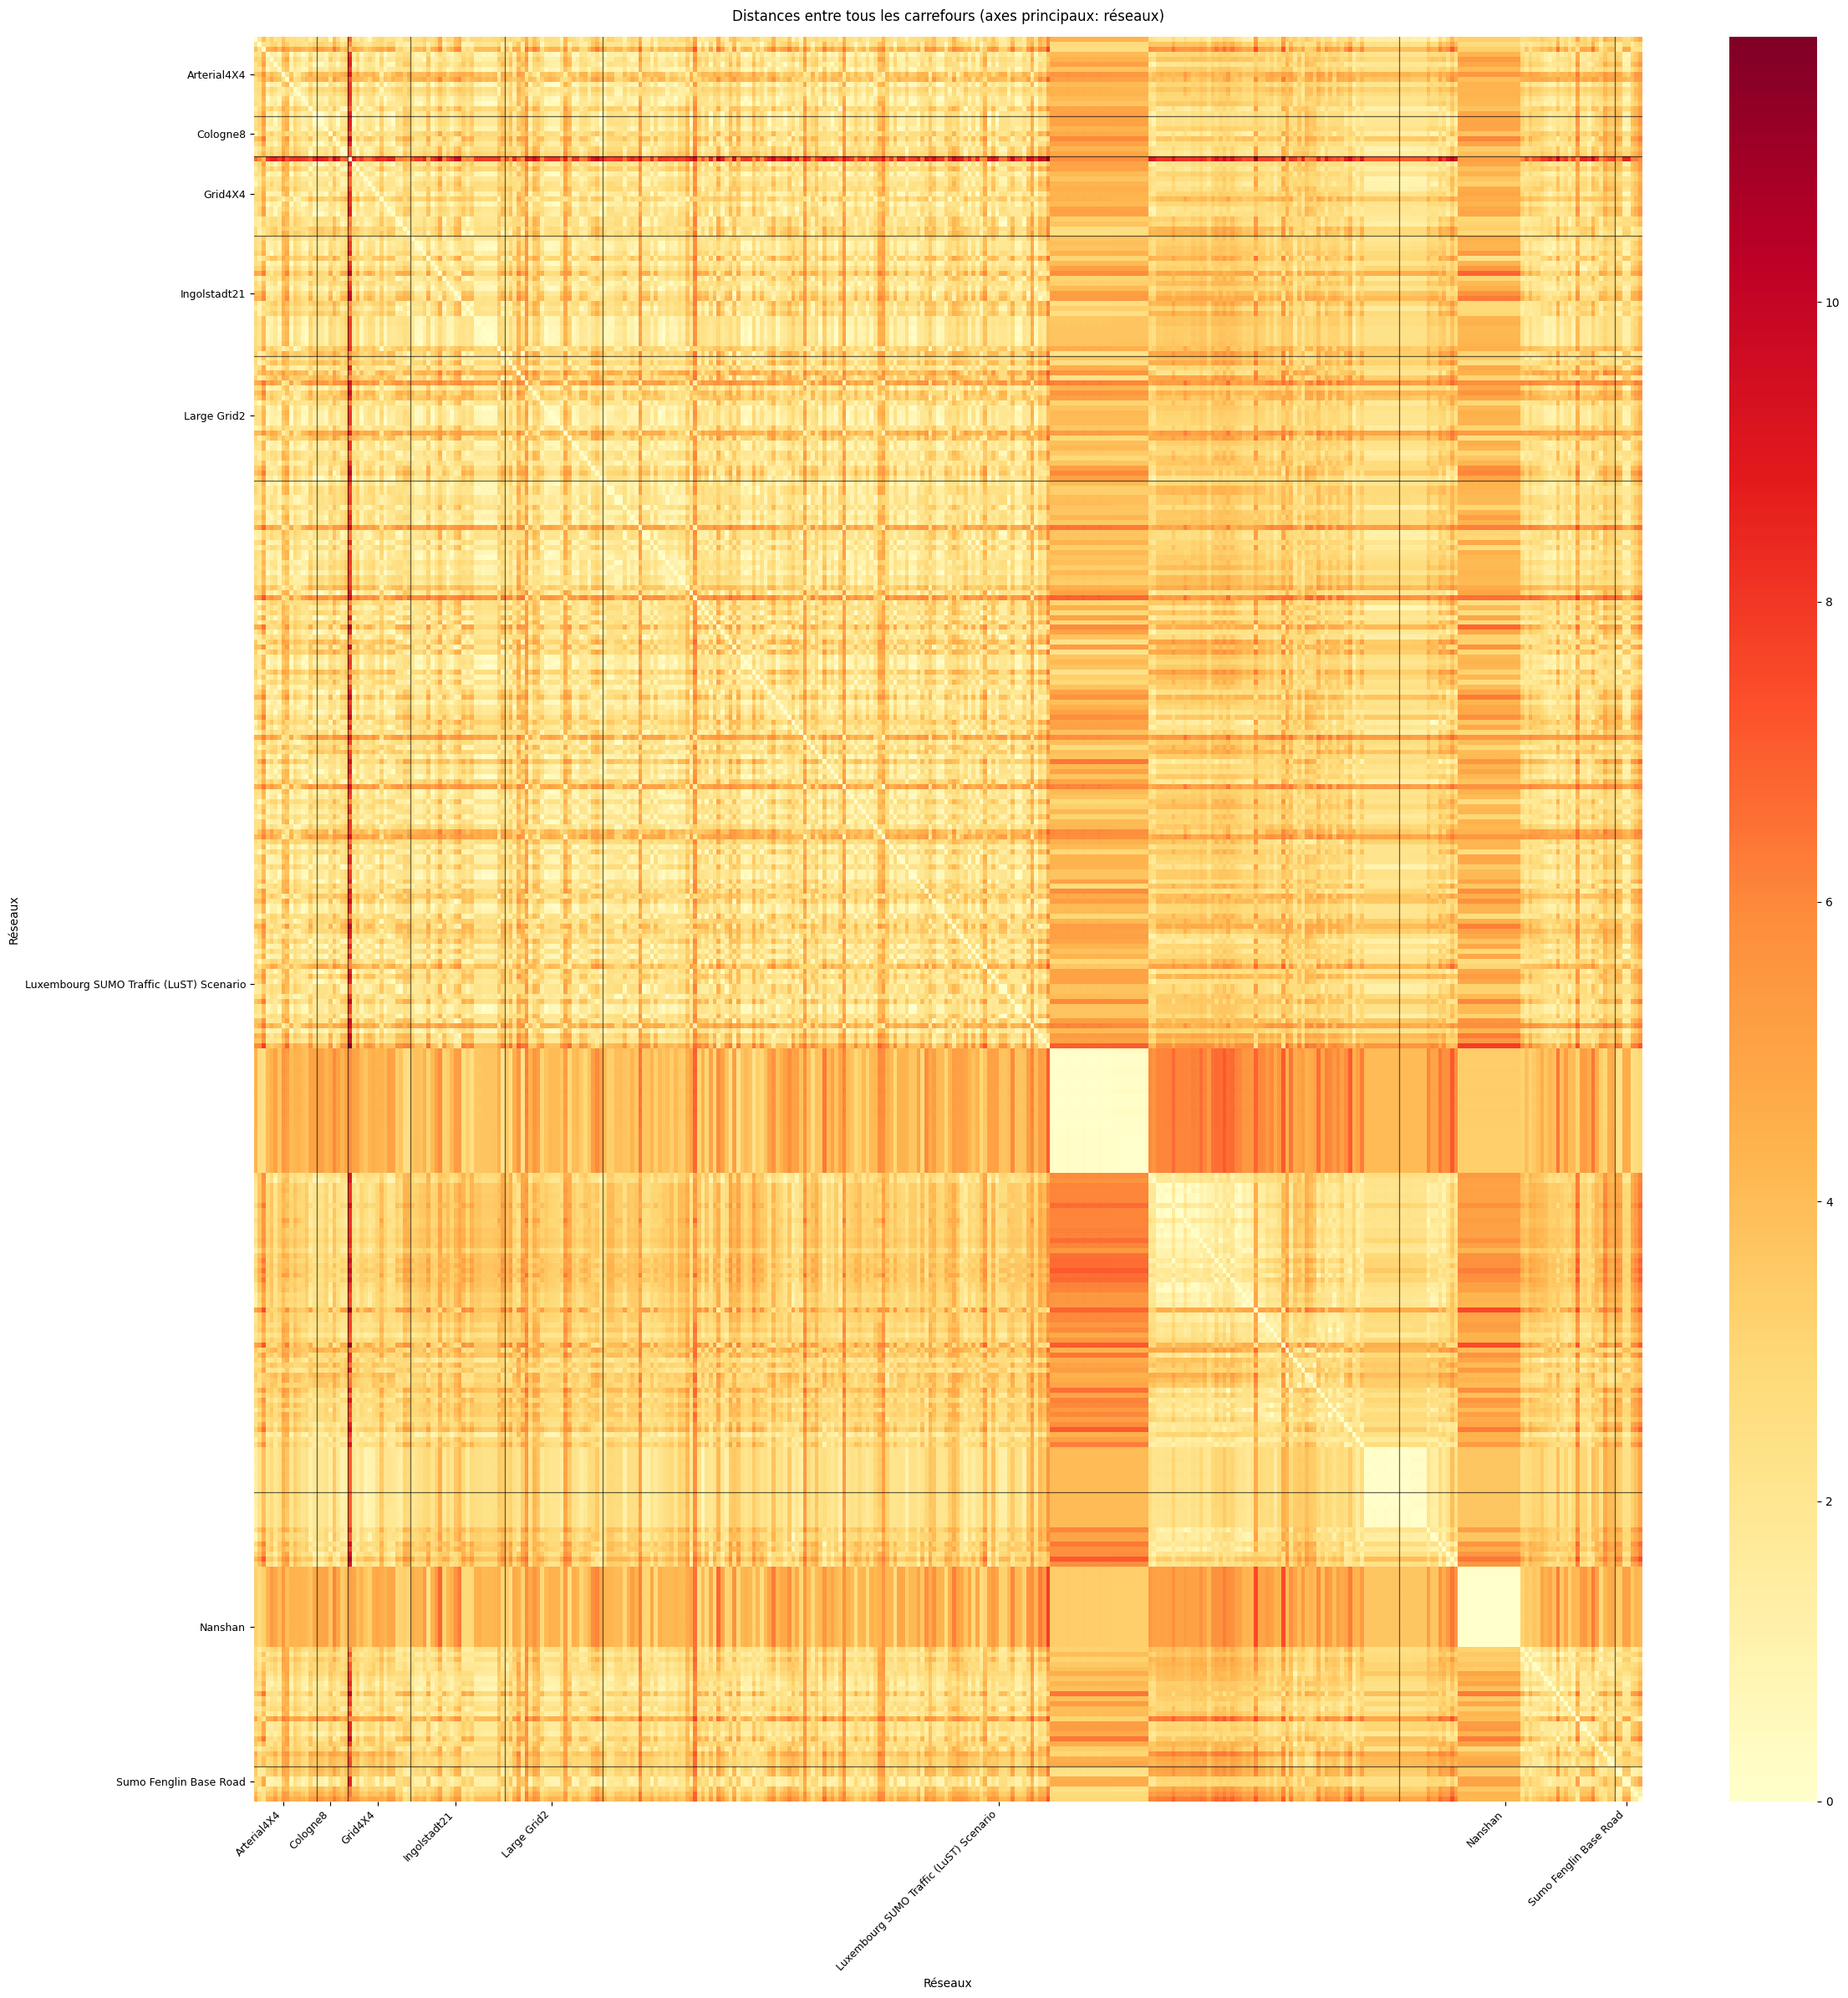

Version interactive non disponible: name 'show_plotly_figure' is not defined
Matrice calculée: 354 carrefours au total sur 8 réseaux.


In [6]:
# --- SECTION 0.1 : Matrice de distance tous carrefours (version lisible + interactive) ---

# 1) Empiler tous les carrefours avec un index hiérarchique (réseau, carrefour)
frames = []
for fichier in sorted(fichiers_net):
    nom_reseau = pretty_network_name(fichier)
    df_local = extract_intersection_features(fichier).copy()
    if df_local.empty:
        continue
    df_local.index = pd.Index(df_local.index.astype(str), name="carrefour")
    frames.append((nom_reseau, df_local))

if not frames:
    print("Aucun carrefour exploitable trouvé pour construire la matrice de distances.")
else:
    df_all = pd.concat(
        [df for _, df in frames],
        keys=[nom for nom, _ in frames],
        names=["reseau", "carrefour"],
    )

    # 2) Normalisation globale des variables locales puis calcul des distances pairwise
    scaler_all = StandardScaler()
    all_norm = scaler_all.fit_transform(df_all.values)
    mat_dist_carrefours = distance_matrix(all_norm, all_norm)

    df_distances_carrefours = pd.DataFrame(
        mat_dist_carrefours,
        index=df_all.index,
        columns=df_all.index,
    )

    # 3) Préparer la structure de groupes (réseaux)
    tailles_reseaux = df_all.groupby(level="reseau").size()
    reseaux = list(tailles_reseaux.index)
    bornes = np.cumsum(tailles_reseaux.values)
    debuts = np.r_[0, bornes[:-1]]
    centres = (debuts + bornes - 1) / 2.0

    # 4) Heatmap statique lisible: pas de labels carrefour, axes principaux = réseaux
    n = len(df_distances_carrefours)
    fig_size = max(10, min(24, n * 0.11))
    plt.figure(figsize=(fig_size, fig_size))
    ax = sns.heatmap(
        df_distances_carrefours,
        cmap="YlOrRd",
        annot=False,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
    )

    # Séparateurs entre blocs de réseaux
    for b in bornes[:-1]:
        ax.axhline(b, color="black", linewidth=0.9, alpha=0.6)
        ax.axvline(b, color="black", linewidth=0.9, alpha=0.6)

    # Noms de réseaux comme axes principaux
    ax.set_xticks(centres)
    ax.set_xticklabels(reseaux, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(centres)
    ax.set_yticklabels(reseaux, rotation=0, fontsize=9)

    plt.title("Distances entre tous les carrefours (axes principaux: réseaux)", pad=14)
    plt.xlabel("Réseaux")
    plt.ylabel("Réseaux")
    plt.tight_layout()
    plt.show()

    # 5) Version interactive: détails réseau/carrefour au survol
    try:
        if go is None:
            raise ImportError('plotly not available')

        idx = df_all.index.to_list()
        labels = [f"{r} | {c}" for r, c in idx]
        z = df_distances_carrefours.values

        hover_text = [
            [
                f"Ligne: {labels[i]}<br>Colonne: {labels[j]}<br>Distance: {z[i, j]:.3f}"
                for j in range(z.shape[1])
            ]
            for i in range(z.shape[0])
        ]

        fig = go.Figure(
            data=go.Heatmap(
                z=z,
                colorscale="YlOrRd",
                text=hover_text,
                hoverinfo="text",
                colorbar=dict(title="Distance"),
            )
        )

        for b in bornes[:-1]:
            fig.add_shape(type="line", x0=b, x1=b, y0=0, y1=n, line=dict(color="black", width=1))
            fig.add_shape(type="line", x0=0, x1=n, y0=b, y1=b, line=dict(color="black", width=1))

        fig.update_layout(
            title="Matrice interactive tous carrefours (survol: réseau/carrefour)",
            xaxis=dict(tickmode="array", tickvals=centres.tolist(), ticktext=reseaux, tickangle=45, title="Réseaux"),
            yaxis=dict(tickmode="array", tickvals=centres.tolist(), ticktext=reseaux, title="Réseaux"),
            width=900,
            height=850,
        )
        show_plotly_figure(fig)
    except Exception as e:
        print(f"Version interactive non disponible: {e}")

    print(f"Matrice calculée: {n} carrefours au total sur {len(tailles_reseaux)} réseaux.")


## Distances inter-réseaux
Comparaison des réseaux à partir de signatures de carrefours, de patchs et d’agrégations de distances minimales.

### Section 1 - Carrefour seul

#### Section 1.1 - Paramètres locaux
Distances réseau basées sur les caractéristiques locales moyennes des carrefours.

Section 1 — préparation des signatures locales/globales/combinées


--- Locaux (moyennes carrefours) — features utilisées: ['prop_voies_dediees', 'voies_entrantes', 'voies_sortantes', 'nb_phases', 'longueur_moy_entree', 'branches'] ---


,prop_voies_dediees,voies_entrantes,voies_sortantes,nb_phases,longueur_moy_entree,branches
Luxembourg SUMO Traffic (LuST) Scenario,0.537,7.502,7.502,6.325,217.432,3.246
Large Grid2,1.000,12.000,12.000,16.000,150.520,4.000
Nanshan,0.115,5.418,5.418,2.273,205.413,3.691
Arterial4X4,0.333,6.000,6.000,10.000,154.450,4.000
Cologne8,0.062,4.125,4.125,6.250,147.782,3.375
Grid4X4,0.000,12.000,12.000,16.000,276.200,4.000
Ingolstadt21,0.468,10.208,8.042,4.083,66.026,3.125
Sumo Fenglin Base Road,0.784,12.143,8.429,6.857,133.319,3.714



Matrice des distances (Locaux (moyennes carrefours)) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,4.156,2.277,2.785,2.515,4.201,2.782,2.632
Large Grid2,4.156,0.000,5.234,3.780,5.530,3.675,4.484,2.570
Nanshan,2.277,5.234,0.000,2.165,1.721,4.587,3.611,3.521
Arterial4X4,2.785,3.780,2.165,0.000,2.378,3.939,3.638,2.807
Cologne8,2.515,5.530,1.721,2.378,0.000,5.235,3.185,3.884
Grid4X4,4.201,3.675,4.587,3.939,5.235,0.000,5.486,4.178
Ingolstadt21,2.782,4.484,3.611,3.638,3.185,5.486,0.000,2.463
Sumo Fenglin Base Road,2.632,2.570,3.521,2.807,3.884,4.178,2.463,0.000


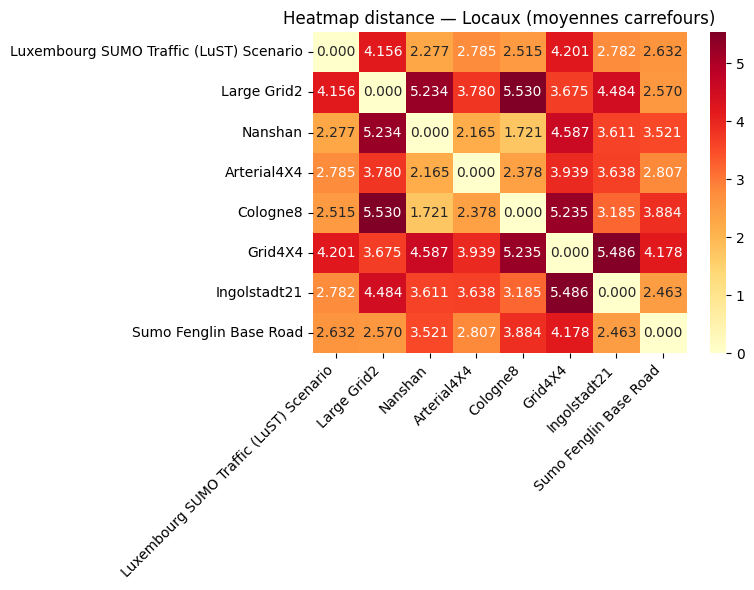


PCA (Locaux (moyennes carrefours)) — variance expliquée PC1+PC2: 81.1%


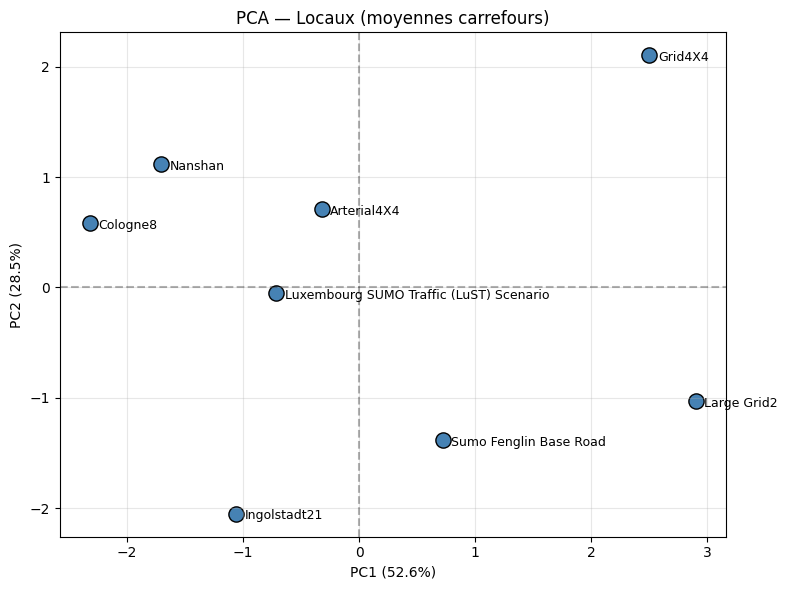

In [7]:
# --- SECTION 1.1 : Locaux — préparation + matrice des distances et PCA (avec valeurs) ---

print("Section 1 — préparation des signatures locales/globales/combinées\n")

# Colonnes locales choisies
local_cols = [
    'prop_voies_dediees',
    'voies_entrantes',
    'voies_sortantes',
    'nb_phases',
    'longueur_moy_entree',
    'branches',
]

# Construire signatures par réseau
sign_local = {}
sign_global = {}
sign_combined = {}
nodes_per_network = {}

for fichier in sorted(fichiers_net):
    nom = pretty_network_name(fichier)
    try:
        df_nodes = extract_intersection_features(fichier)
        net_feats = extract_network_features(fichier)
    except Exception as e:
        print(f"Échec lecture {nom}: {e}")
        continue

    nodes_per_network[nom] = df_nodes
    if df_nodes is None or df_nodes.empty:
        sign_local[nom] = pd.Series({c:0.0 for c in local_cols})
    else:
        # moyenne des variables locales
        sign_local[nom] = df_nodes.reindex(columns=local_cols).mean().astype(float)

    sign_global[nom] = pd.Series({
        'n_junctions': float(net_feats.get('n_junctions',0)),
        'n_links': float(net_feats.get('n_links',0)),
        'avg_link_length': float(net_feats.get('avg_link_length',0)),
    })

    sign_combined[nom] = pd.concat([sign_global[nom], sign_local[nom]])

# Helper pipeline (affiche heatmap ANNOTÉE et PCA)
def compute_and_plot(sig_dict, title_prefix, annotate=True):
    df = pd.DataFrame(sig_dict).T.fillna(0.0)
    print(f"\n--- {title_prefix} — features utilisées: {list(df.columns)} ---")
    display(df.round(3))

    scaler = StandardScaler()
    X = scaler.fit_transform(df.values)
    df_norm = pd.DataFrame(X, index=df.index, columns=df.columns)
    mat = distance_matrix(X, X)
    df_dist = pd.DataFrame(mat, index=df.index, columns=df.index)

    print(f"\nMatrice des distances ({title_prefix}) :")
    display(df_dist.round(3))

    plt.figure(figsize=(8,6))
    sns.heatmap(df_dist, cmap='YlOrRd', annot=annotate, fmt='.3f', xticklabels=True, yticklabels=True)
    plt.title(f"Heatmap distance — {title_prefix}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    pca = PCA(n_components=2)
    comps = pca.fit_transform(df_norm.values)
    df_pca = pd.DataFrame(comps, index=df.index, columns=['PC1','PC2'])
    var = pca.explained_variance_ratio_
    print(f"\nPCA ({title_prefix}) — variance expliquée PC1+PC2: {(var[0]+var[1])*100:.1f}%")
    plt.figure(figsize=(8,6))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], s=120, c='steelblue', edgecolors='black')
    for nom in df_pca.index:
        plt.annotate(nom, (df_pca.loc[nom,'PC1'], df_pca.loc[nom,'PC2']), xytext=(6,-4), textcoords='offset points', fontsize=9)
    plt.xlabel(f"PC1 ({var[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({var[1]*100:.1f}%)")
    plt.title(f"PCA — {title_prefix}")
    plt.axhline(0,color='k',linestyle='--',alpha=0.3)
    plt.axvline(0,color='k',linestyle='--',alpha=0.3)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df, df_norm, df_dist, df_pca

# Exécuter la section 1 (Locaux)
df_local, df_local_norm, df_local_dist, df_local_pca = compute_and_plot(sign_local, 'Locaux (moyennes carrefours)', annotate=True)

#### Section 1.2 - Paramètres globaux
Distances réseau basées uniquement sur les métriques globales du réseau.


--- Globaux — features utilisées: ['n_junctions', 'n_links', 'avg_link_length'] ---


,n_junctions,n_links,avg_link_length
Luxembourg SUMO Traffic (LuST) Scenario,201.0,5779.0,160.804
Large Grid2,25.0,120.0,135.667
Nanshan,55.0,2072.0,181.993
Arterial4X4,16.0,80.0,137.680
Cologne8,8.0,149.0,98.908
Grid4X4,16.0,80.0,278.240
Ingolstadt21,21.0,853.0,82.965
Sumo Fenglin Base Road,7.0,106.0,213.075



Matrice des distances (Globaux) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,4.205,3.128,4.319,4.492,4.737,4.169,4.485
Large Grid2,4.205,0.000,1.396,0.153,0.681,2.413,0.976,1.341
Nanshan,3.128,1.396,0.000,1.452,1.904,2.048,1.880,1.416
Arterial4X4,4.319,0.153,1.452,0.000,0.669,2.375,1.016,1.282
Cologne8,4.492,0.681,1.904,0.669,0.000,3.033,0.510,1.929
Grid4X4,4.737,2.413,2.048,2.375,3.033,0.000,3.326,1.111
Ingolstadt21,4.169,0.976,1.880,1.016,0.510,3.326,0.000,2.246
Sumo Fenglin Base Road,4.485,1.341,1.416,1.282,1.929,1.111,2.246,0.000


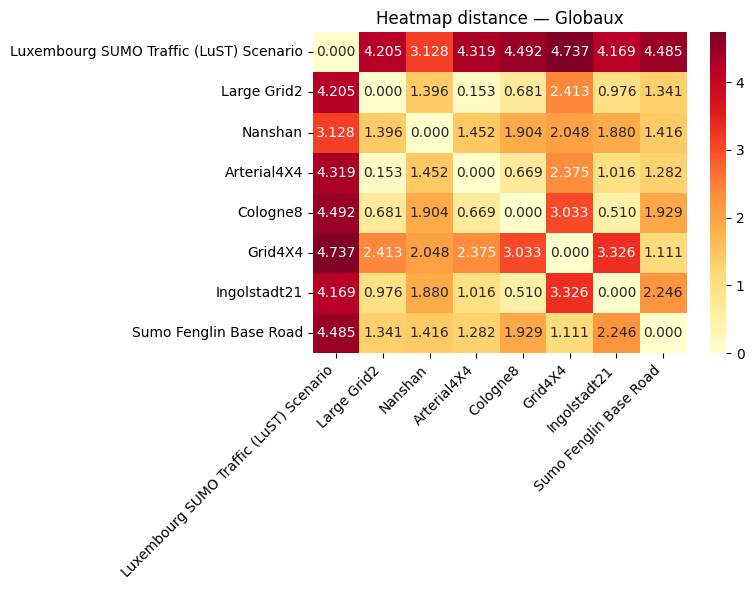


PCA (Globaux) — variance expliquée PC1+PC2: 99.5%


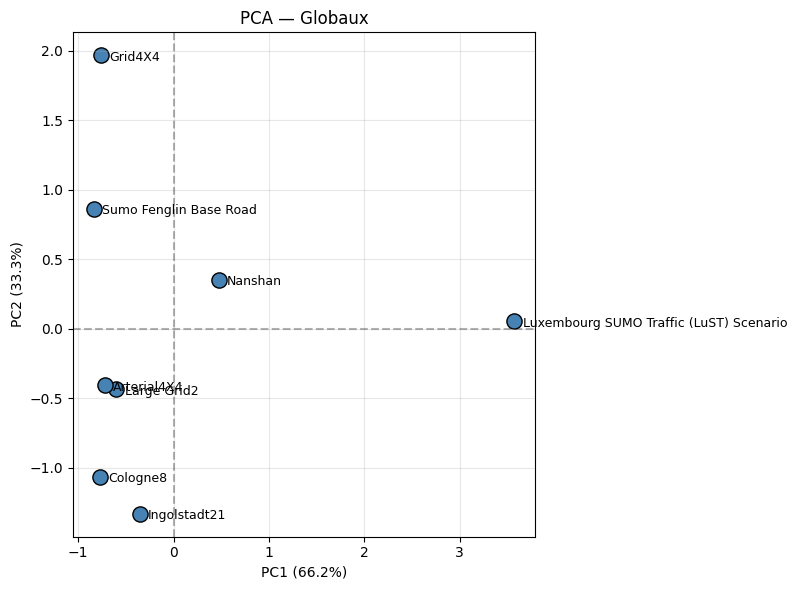

In [8]:
# --- SECTION 1.2 : Globaux seulement — matrice des distances et PCA (avec valeurs) ---
# Utilise `sign_global` préparé dans la section précédente
df_global, df_global_norm, df_global_dist, df_global_pca = compute_and_plot(sign_global, 'Globaux', annotate=True)

#### Section 1.3 - Paramètres combinés
Distances réseau basées sur la concaténation des paramètres locaux et globaux.


--- Combiné (global + local) — features utilisées: ['n_junctions', 'n_links', 'avg_link_length', 'prop_voies_dediees', 'voies_entrantes', 'voies_sortantes', 'nb_phases', 'longueur_moy_entree', 'branches'] ---


,n_junctions,n_links,avg_link_length,prop_voies_dediees,voies_entrantes,voies_sortantes,nb_phases,longueur_moy_entree,branches
Luxembourg SUMO Traffic (LuST) Scenario,201.0,5779.0,160.804,0.537,7.502,7.502,6.325,217.432,3.246
Large Grid2,25.0,120.0,135.667,1.000,12.000,12.000,16.000,150.520,4.000
Nanshan,55.0,2072.0,181.993,0.115,5.418,5.418,2.273,205.413,3.691
Arterial4X4,16.0,80.0,137.680,0.333,6.000,6.000,10.000,154.450,4.000
Cologne8,8.0,149.0,98.908,0.062,4.125,4.125,6.250,147.782,3.375
Grid4X4,16.0,80.0,278.240,0.000,12.000,12.000,16.000,276.200,4.000
Ingolstadt21,21.0,853.0,82.965,0.468,10.208,8.042,4.083,66.026,3.125
Sumo Fenglin Base Road,7.0,106.0,213.075,0.784,12.143,8.429,6.857,133.319,3.714



Matrice des distances (Combiné (global + local)) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,5.912,3.869,5.139,5.149,6.331,5.012,5.200
Large Grid2,5.912,0.000,5.417,3.783,5.571,4.397,4.589,2.899
Nanshan,3.869,5.417,0.000,2.607,2.566,5.024,4.071,3.795
Arterial4X4,5.139,3.783,2.607,0.000,2.470,4.599,3.777,3.086
Cologne8,5.149,5.571,2.566,2.470,0.000,6.050,3.225,4.336
Grid4X4,6.331,4.397,5.024,4.599,6.050,0.000,6.415,4.323
Ingolstadt21,5.012,4.589,4.071,3.777,3.225,6.415,0.000,3.333
Sumo Fenglin Base Road,5.200,2.899,3.795,3.086,4.336,4.323,3.333,0.000


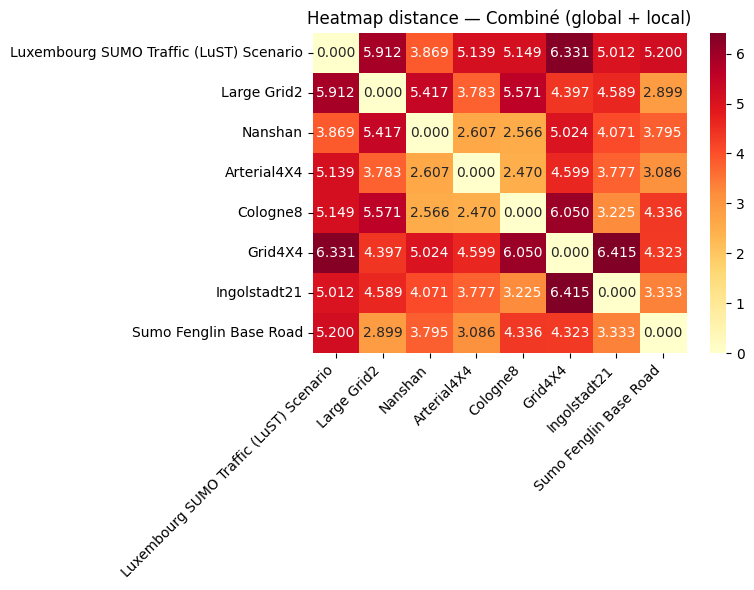


PCA (Combiné (global + local)) — variance expliquée PC1+PC2: 67.5%


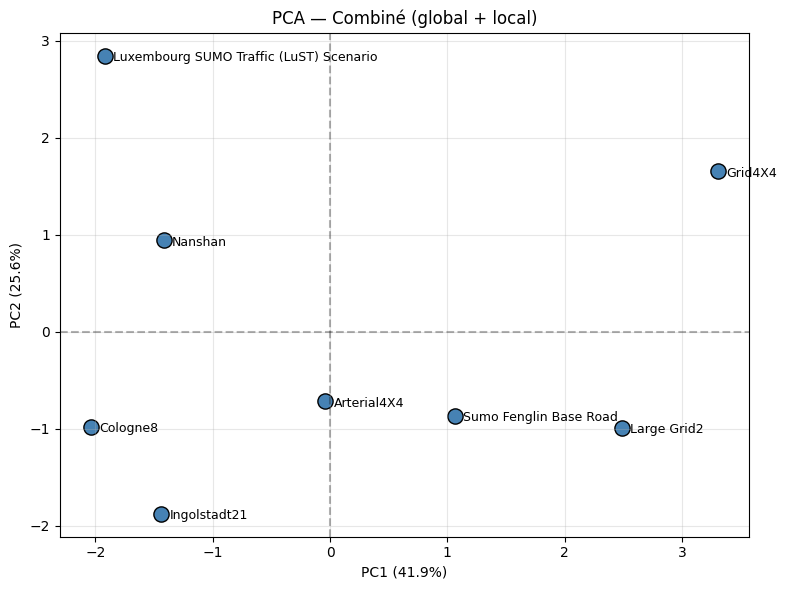

In [9]:
# --- SECTION 1.3 : Combiné (local + global) — matrice des distances et PCA (avec valeurs) ---
df_comb, df_comb_norm, df_comb_dist, df_comb_pca = compute_and_plot(sign_combined, 'Combiné (global + local)', annotate=True)

#### Section 1.4 - Méthode minima composite
Distances réseau construites à partir des minima noeud-à-noeud et agrégées en une matrice unique.


Matrice composite unique (basée sur min / max / mean / std des minima) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,0.907,0.752,1.141,1.119,0.988,0.872,0.904
Large Grid2,0.907,0.000,1.431,1.043,1.591,0.753,0.900,0.699
Nanshan,0.752,1.431,0.000,0.593,0.837,1.229,0.613,0.412
Arterial4X4,1.141,1.043,0.593,0.000,0.679,0.863,0.614,0.628
Cologne8,1.119,1.591,0.837,0.679,0.000,1.125,0.545,0.604
Grid4X4,0.988,0.753,1.229,0.863,1.125,0.000,0.889,0.834
Ingolstadt21,0.872,0.900,0.613,0.614,0.545,0.889,0.000,0.549
Sumo Fenglin Base Road,0.904,0.699,0.412,0.628,0.604,0.834,0.549,0.000


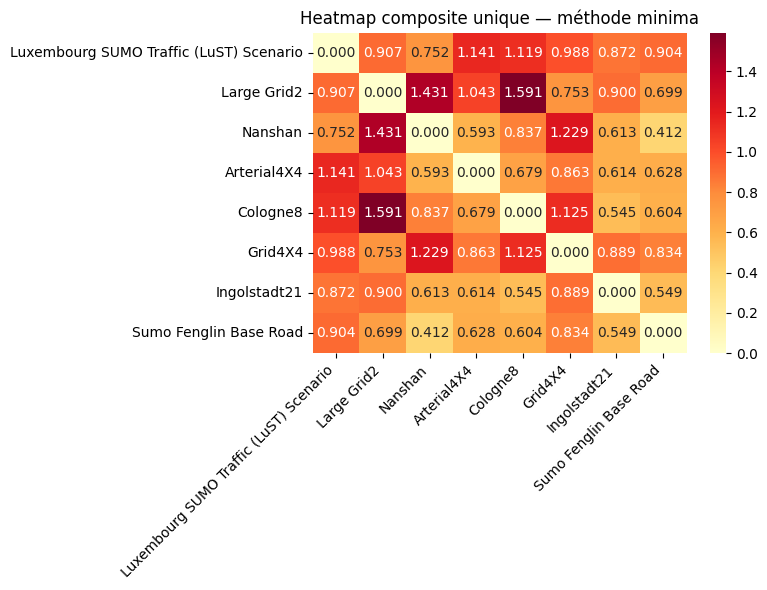


PCA (matrice composite unique) — variance PC1+PC2: 67.9%


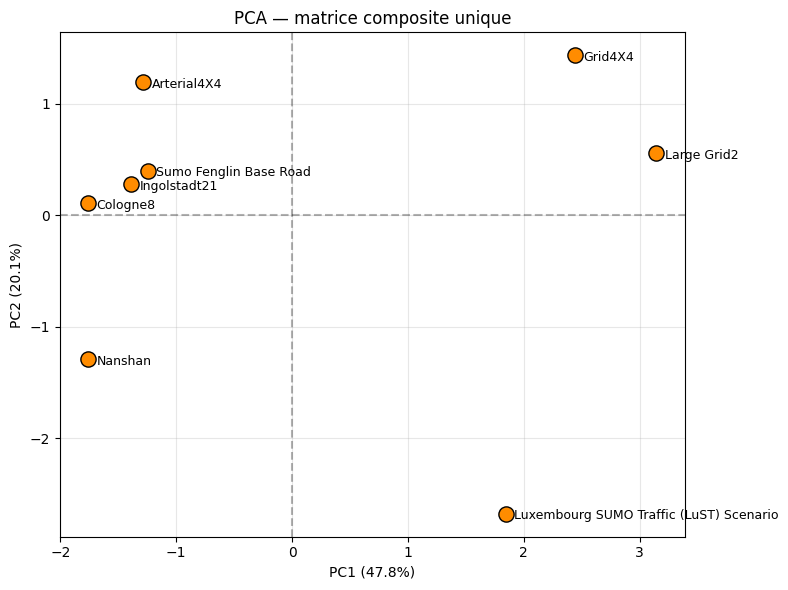

In [10]:
# --- SECTION 1.4 : Méthode minima — matrice composite unique basée sur min / max / mean / std ---
# Idée : on garde les 4 statistiques issues des distances minimales,
# puis on les combine en une seule distance composite après normalisation.
all_nodes_list = []
net_keys = list(nodes_per_network.keys())

for net in net_keys:
    dfn = nodes_per_network.get(net)
    if dfn is None or dfn.empty:
        continue
    dfn2 = dfn.reindex(columns=local_cols).fillna(0.0)
    dfn2.index = pd.MultiIndex.from_product([[net], dfn2.index], names=['reseau', 'carrefour'])
    all_nodes_list.append(dfn2)

if not all_nodes_list:
    print('Aucun noeud disponible pour method minima.')
else:
    df_all_nodes = pd.concat(all_nodes_list)
    scaler_nodes = StandardScaler()
    X_nodes = scaler_nodes.fit_transform(df_all_nodes.values)
    df_all_nodes_norm = pd.DataFrame(X_nodes, index=df_all_nodes.index, columns=df_all_nodes.columns)

    K = len(net_keys)
    mat_minmin = np.zeros((K, K))
    mat_maxmin = np.zeros((K, K))
    mat_meanmin = np.zeros((K, K))
    mat_stdmin = np.zeros((K, K))

    for i, net_i in enumerate(net_keys):
        idx_i = [idx for idx in df_all_nodes_norm.index if idx[0] == net_i]
        Xi = df_all_nodes_norm.loc[idx_i].values if idx_i else np.empty((0, df_all_nodes_norm.shape[1]))

        for j, net_j in enumerate(net_keys):
            idx_j = [idx for idx in df_all_nodes_norm.index if idx[0] == net_j]
            Xj = df_all_nodes_norm.loc[idx_j].values if idx_j else np.empty((0, df_all_nodes_norm.shape[1]))

            if Xi.size == 0 or Xj.size == 0:
                mat_minmin[i, j] = np.nan
                mat_maxmin[i, j] = np.nan
                mat_meanmin[i, j] = np.nan
                mat_stdmin[i, j] = np.nan
                continue

            D = distance_matrix(Xi, Xj)
            mins = D.min(axis=1)

            mat_minmin[i, j] = float(mins.min())
            mat_maxmin[i, j] = float(mins.max())
            mat_meanmin[i, j] = float(mins.mean())
            mat_stdmin[i, j] = float(mins.std(ddof=0))

    df_minmin = pd.DataFrame(mat_minmin, index=net_keys, columns=net_keys)
    df_maxmin = pd.DataFrame(mat_maxmin, index=net_keys, columns=net_keys)
    df_meanmin = pd.DataFrame(mat_meanmin, index=net_keys, columns=net_keys)
    df_stdmin = pd.DataFrame(mat_stdmin, index=net_keys, columns=net_keys)

    # Construction d'une distance composite unique :
    # on normalise chaque statistique puis on prend la norme euclidienne des 4 composantes.
    feature_stack = np.stack(
        [
            df_minmin.values,
            df_maxmin.values,
            df_meanmin.values,
            df_stdmin.values,
        ],
        axis=-1,
    )

    composite = np.zeros((K, K), dtype=float)
    for feature_idx in range(feature_stack.shape[-1]):
        feature = feature_stack[:, :, feature_idx].astype(float)
        mask = np.isfinite(feature)
        values = feature[mask].reshape(-1, 1)
        scaler_feat = StandardScaler()
        z_values = scaler_feat.fit_transform(values).ravel()
        z_feature = np.full(feature.shape, np.nan, dtype=float)
        z_feature[mask] = z_values
        feature_stack[:, :, feature_idx] = z_feature

    # moyenne des carrés des 4 statistiques normalisées -> une seule matrice
    composite = np.sqrt(np.nanmean(np.square(feature_stack), axis=-1))

    # symétrisation pour obtenir une vraie matrice réseau-réseau
    composite = (composite + composite.T) / 2.0
    np.fill_diagonal(composite, 0.0)
    df_composite = pd.DataFrame(composite, index=net_keys, columns=net_keys)

    print('\nMatrice composite unique (basée sur min / max / mean / std des minima) :')
    display(df_composite.round(3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_composite, cmap='YlOrRd', annot=True, fmt='.3f')
    plt.title('Heatmap composite unique — méthode minima')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # PCA sur la matrice composite unique
    scaler_comp = StandardScaler()
    X_comp = scaler_comp.fit_transform(df_composite.values)
    pca_comp = PCA(n_components=2)
    comps_comp = pca_comp.fit_transform(X_comp)
    df_pca_comp = pd.DataFrame(comps_comp, index=df_composite.index, columns=['PC1', 'PC2'])
    var_comp = pca_comp.explained_variance_ratio_

    print(f"\nPCA (matrice composite unique) — variance PC1+PC2: {(var_comp[0] + var_comp[1]) * 100:.1f}%")
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca_comp['PC1'], df_pca_comp['PC2'], s=120, c='darkorange', edgecolors='black')
    for net in df_pca_comp.index:
        plt.annotate(net, (df_pca_comp.loc[net, 'PC1'], df_pca_comp.loc[net, 'PC2']), xytext=(6, -4), textcoords='offset points', fontsize=9)
    plt.xlabel(f"PC1 ({var_comp[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({var_comp[1] * 100:.1f}%)")
    plt.title('PCA — matrice composite unique')
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Section 1.5 - Fusion des 3 distances
Fusion unique des matrices locales, globales et minima après normalisation, puis heatmap et PCA sur la matrice combinée.

In [11]:
def combine_three_distance_matrices(distance_matrices, matrix_labels, result_name):
    reference_index = distance_matrices[0].index
    aligned_values = []
    aligned_masks = []
    stacked_off_diag = []

    for matrix in distance_matrices:
        aligned = matrix.reindex(index=reference_index, columns=reference_index).astype(float)
        values = aligned.values
        mask = ~np.eye(values.shape[0], dtype=bool)
        off_diag = values[mask].reshape(-1, 1)

        aligned_values.append(values)
        aligned_masks.append(mask)
        if off_diag.size > 0:
            stacked_off_diag.append(off_diag)

    if stacked_off_diag:
        stacked_values = np.vstack(stacked_off_diag)
        common_z_scaler = StandardScaler()
        z_all = common_z_scaler.fit_transform(stacked_values).ravel()
        positive_scaler = MinMaxScaler()
        positive_scaler.fit(z_all.reshape(-1, 1))
    else:
        common_z_scaler = None
        positive_scaler = None

    aligned_matrices = []
    for values, mask in zip(aligned_values, aligned_masks):
        if common_z_scaler is None or positive_scaler is None or values.size == 0:
            normalized = values.copy()
        else:
            normalized = np.zeros_like(values, dtype=float)
            z_values = common_z_scaler.transform(values[mask].reshape(-1, 1)).ravel()
            positive_values = positive_scaler.transform(z_values.reshape(-1, 1)).ravel()
            normalized[mask] = positive_values
            normalized = (normalized + normalized.T) / 2.0
            np.fill_diagonal(normalized, 0.0)

        aligned_matrices.append(normalized)

    combined_matrix = np.mean(aligned_matrices, axis=0)
    np.fill_diagonal(combined_matrix, 0.0)
    df_combined = pd.DataFrame(combined_matrix, index=reference_index, columns=reference_index)

    print(f"\nMatrice de consensus unique ({result_name}) :")
    display(df_combined.round(3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_combined, cmap='YlOrRd', annot=True, fmt='.3f')
    plt.title(f"Heatmap consensus unique — {result_name}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    scaler = StandardScaler()
    X = scaler.fit_transform(df_combined.values)
    pca = PCA(n_components=2)
    comps = pca.fit_transform(X)
    df_pca = pd.DataFrame(comps, index=df_combined.index, columns=['PC1', 'PC2'])
    var = pca.explained_variance_ratio_

    print(f"\nPCA ({result_name}) — variance PC1+PC2: {(var[0] + var[1]) * 100:.1f}%")
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], s=120, c='teal', edgecolors='black')
    for item in df_pca.index:
        plt.annotate(item, (df_pca.loc[item, 'PC1'], df_pca.loc[item, 'PC2']), xytext=(6, -4), textcoords='offset points', fontsize=9)
    plt.xlabel(f"PC1 ({var[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({var[1] * 100:.1f}%)")
    plt.title(f"PCA — {result_name}")
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_combined, df_pca

### Section 2 - voisinage direct des carrefours
Les sections suivantes remplacent le carrefour seul par un patch : carrefour centre + voisins directs reliés par un lien.

In [12]:
# --- SECTION 2 : Préparation des signatures de patchs de carrefours ---
def extract_patch_features(net_file_path):
    """Extrait des caractéristiques de patch pour chaque carrefour.
    Un patch = le carrefour lui-même + ses voisins directs reliés par un lien.
    Les caractéristiques du patch sont la moyenne des variables locales sur ce patch.
    """
    chemin_securise = pathlib.Path(net_file_path).resolve().as_uri()
    net = sumolib.net.readNet(chemin_securise, withPrograms=True)
    df_nodes = extract_intersection_features(net_file_path).copy()

    if df_nodes.empty:
        return df_nodes

    traffic_nodes = {node.getID(): node for node in net.getNodes() if node.getType().startswith('traffic_light')}

    def direct_neighbor_ids(node_obj):
        neighbors = set()
        for edge in node_obj.getIncoming():
            edge_id = edge.getID()
            if edge_id.startswith(':'):
                continue
            from_node = edge.getFromNode()
            if from_node is not None and from_node.getType().startswith('traffic_light'):
                neighbors.add(from_node.getID())
        for edge in node_obj.getOutgoing():
            edge_id = edge.getID()
            if edge_id.startswith(':'):
                continue
            to_node = edge.getToNode()
            if to_node is not None and to_node.getType().startswith('traffic_light'):
                neighbors.add(to_node.getID())
        return neighbors

    patch_rows = []
    patch_index = []
    for node_id in df_nodes.index.astype(str):
        center_node = traffic_nodes.get(node_id)
        if center_node is None:
            continue
        patch_ids = {node_id} | direct_neighbor_ids(center_node)
        patch_df = df_nodes.loc[df_nodes.index.intersection(patch_ids)]
        if patch_df.empty:
            patch_df = df_nodes.loc[[node_id]]
        patch_features = patch_df.reindex(columns=local_cols).mean().astype(float)
        patch_rows.append(patch_features)
        patch_index.append(node_id)

    return pd.DataFrame(patch_rows, index=patch_index)

patch_nodes_per_network = {}
patch_sign_local = {}
patch_sign_global = {}
patch_sign_combined = {}

for fichier in sorted(fichiers_net):
    nom = pretty_network_name(fichier)
    try:
        df_patches = extract_patch_features(fichier)
        net_feats = extract_network_features(fichier)
    except Exception as e:
        print(f"Échec lecture patch {nom}: {e}")
        continue

    patch_nodes_per_network[nom] = df_patches
    if df_patches is None or df_patches.empty:
        patch_sign_local[nom] = pd.Series({c: 0.0 for c in local_cols})
    else:
        patch_sign_local[nom] = df_patches.reindex(columns=local_cols).mean().astype(float)

    patch_sign_global[nom] = pd.Series({
        'n_junctions': float(net_feats.get('n_junctions', 0)),
        'n_links': float(net_feats.get('n_links', 0)),
        'avg_link_length': float(net_feats.get('avg_link_length', 0)),
    })
    patch_sign_combined[nom] = pd.concat([patch_sign_global[nom], patch_sign_local[nom]])

print("Préparation patch terminée : signatures calculées pour tous les réseaux.\n")

Préparation patch terminée : signatures calculées pour tous les réseaux.



#### Section 2.1 — Locaux sur patchs
Matrice des distances et PCA à partir des moyennes de patchs de voisinage direct.


--- Locaux sur patchs (moyennes des voisinages directs) — features utilisées: ['prop_voies_dediees', 'voies_entrantes', 'voies_sortantes', 'nb_phases', 'longueur_moy_entree', 'branches'] ---


,prop_voies_dediees,voies_entrantes,voies_sortantes,nb_phases,longueur_moy_entree,branches
Luxembourg SUMO Traffic (LuST) Scenario,0.537,7.521,7.530,6.330,219.476,3.249
Large Grid2,1.000,12.000,12.000,16.000,151.931,4.000
Nanshan,0.114,5.417,5.435,2.239,206.089,3.682
Arterial4X4,0.333,6.000,6.000,10.000,156.313,4.000
Cologne8,0.062,4.167,4.167,6.250,145.964,3.375
Grid4X4,0.000,12.000,12.000,16.000,275.973,4.000
Ingolstadt21,0.467,10.278,8.097,4.139,65.200,3.132
Sumo Fenglin Base Road,0.784,12.143,8.429,6.857,133.319,3.714



Matrice des distances (Locaux sur patchs (moyennes des voisinages directs)) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,4.156,2.272,2.791,2.538,4.189,2.815,2.643
Large Grid2,4.156,0.000,5.246,3.786,5.526,3.651,4.476,2.577
Nanshan,2.272,5.246,0.000,2.176,1.727,4.595,3.619,3.529
Arterial4X4,2.791,3.786,2.176,0.000,2.383,3.920,3.659,2.815
Cologne8,2.538,5.526,1.727,2.383,0.000,5.236,3.180,3.872
Grid4X4,4.189,3.651,4.595,3.920,5.236,0.000,5.463,4.169
Ingolstadt21,2.815,4.476,3.619,3.659,3.180,5.463,0.000,2.449
Sumo Fenglin Base Road,2.643,2.577,3.529,2.815,3.872,4.169,2.449,0.000


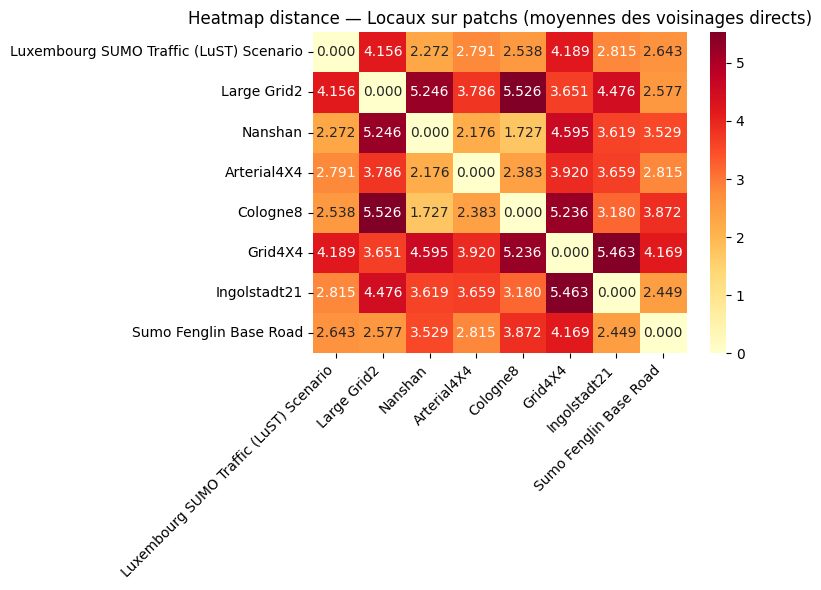


PCA (Locaux sur patchs (moyennes des voisinages directs)) — variance expliquée PC1+PC2: 81.0%


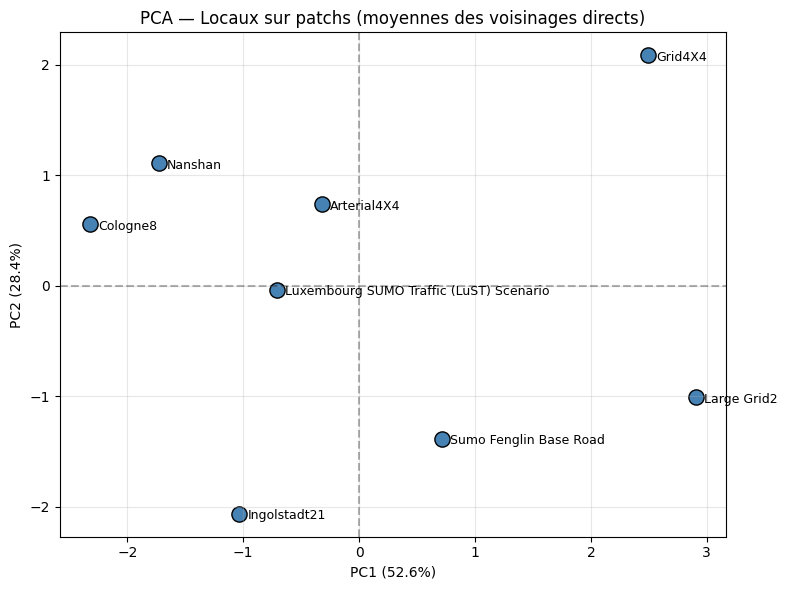

In [13]:
# --- SECTION 2.1 : Locaux sur patchs — matrice des distances et PCA (avec valeurs) ---
df_patch_local, df_patch_local_norm, df_patch_local_dist, df_patch_local_pca = compute_and_plot(patch_sign_local, 'Locaux sur patchs (moyennes des voisinages directs)', annotate=True)

#### Section 2.2 — Globaux sur patchs
Matrice des distances et PCA en conservant les paramètres globaux du réseau.


--- Globaux — features utilisées: ['n_junctions', 'n_links', 'avg_link_length'] ---


,n_junctions,n_links,avg_link_length
Luxembourg SUMO Traffic (LuST) Scenario,201.0,5779.0,160.804
Large Grid2,25.0,120.0,135.667
Nanshan,55.0,2072.0,181.993
Arterial4X4,16.0,80.0,137.680
Cologne8,8.0,149.0,98.908
Grid4X4,16.0,80.0,278.240
Ingolstadt21,21.0,853.0,82.965
Sumo Fenglin Base Road,7.0,106.0,213.075



Matrice des distances (Globaux) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,4.205,3.128,4.319,4.492,4.737,4.169,4.485
Large Grid2,4.205,0.000,1.396,0.153,0.681,2.413,0.976,1.341
Nanshan,3.128,1.396,0.000,1.452,1.904,2.048,1.880,1.416
Arterial4X4,4.319,0.153,1.452,0.000,0.669,2.375,1.016,1.282
Cologne8,4.492,0.681,1.904,0.669,0.000,3.033,0.510,1.929
Grid4X4,4.737,2.413,2.048,2.375,3.033,0.000,3.326,1.111
Ingolstadt21,4.169,0.976,1.880,1.016,0.510,3.326,0.000,2.246
Sumo Fenglin Base Road,4.485,1.341,1.416,1.282,1.929,1.111,2.246,0.000


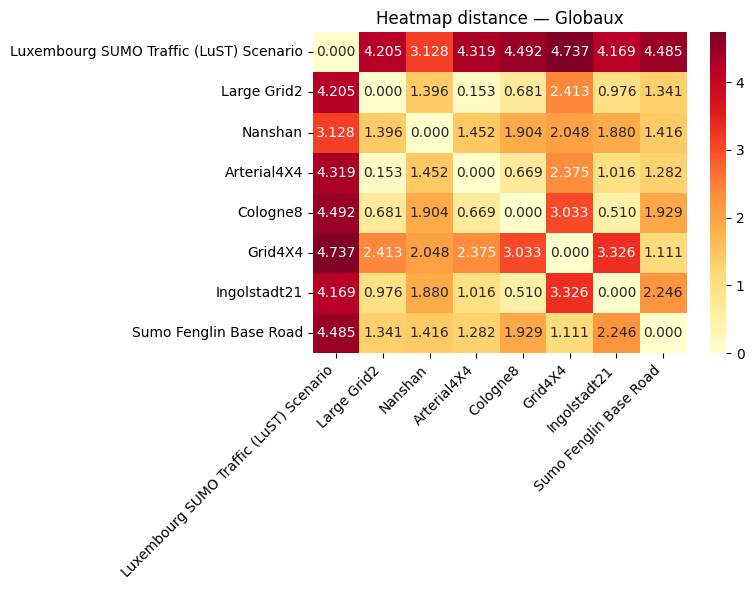


PCA (Globaux) — variance expliquée PC1+PC2: 99.5%


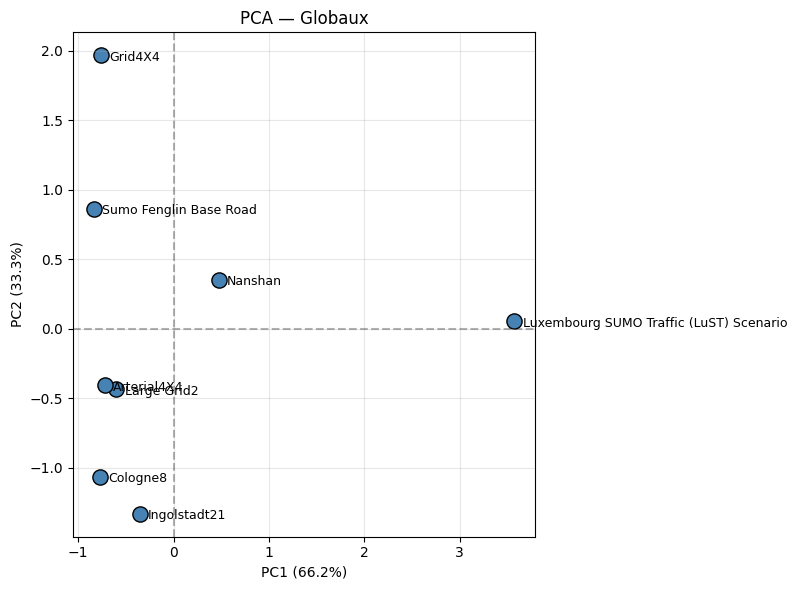

In [14]:
# --- SECTION 2.2 : Globaux sur patchs — matrice des distances et PCA (avec valeurs) ---
# Les paramètres globaux restent calculés au niveau réseau,
patch_df_global = patch_sign_global
df_patch_global, df_patch_global_norm, df_patch_global_dist, df_patch_global_pca = compute_and_plot(patch_df_global, 'Globaux', annotate=True)

#### Section 2.3 — Combiné sur patchs
Matrice des distances et PCA en combinant paramètres locaux et globaux sur patchs.


--- Combiné sur patchs (global + local) — features utilisées: ['n_junctions', 'n_links', 'avg_link_length', 'prop_voies_dediees', 'voies_entrantes', 'voies_sortantes', 'nb_phases', 'longueur_moy_entree', 'branches'] ---


,n_junctions,n_links,avg_link_length,prop_voies_dediees,voies_entrantes,voies_sortantes,nb_phases,longueur_moy_entree,branches
Luxembourg SUMO Traffic (LuST) Scenario,201.0,5779.0,160.804,0.537,7.521,7.530,6.330,219.476,3.249
Large Grid2,25.0,120.0,135.667,1.000,12.000,12.000,16.000,151.931,4.000
Nanshan,55.0,2072.0,181.993,0.114,5.417,5.435,2.239,206.089,3.682
Arterial4X4,16.0,80.0,137.680,0.333,6.000,6.000,10.000,156.313,4.000
Cologne8,8.0,149.0,98.908,0.062,4.167,4.167,6.250,145.964,3.375
Grid4X4,16.0,80.0,278.240,0.000,12.000,12.000,16.000,275.973,4.000
Ingolstadt21,21.0,853.0,82.965,0.467,10.278,8.097,4.139,65.200,3.132
Sumo Fenglin Base Road,7.0,106.0,213.075,0.784,12.143,8.429,6.857,133.319,3.714



Matrice des distances (Combiné sur patchs (global + local)) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,5.913,3.866,5.142,5.160,6.323,5.030,5.205
Large Grid2,5.913,0.000,5.428,3.789,5.568,4.376,4.581,2.905
Nanshan,3.866,5.428,0.000,2.616,2.570,5.031,4.078,3.802
Arterial4X4,5.142,3.789,2.616,0.000,2.475,4.583,3.797,3.094
Cologne8,5.160,5.568,2.570,2.475,0.000,6.051,3.220,4.326
Grid4X4,6.323,4.376,5.031,4.583,6.051,0.000,6.396,4.314
Ingolstadt21,5.030,4.581,4.078,3.797,3.220,6.396,0.000,3.323
Sumo Fenglin Base Road,5.205,2.905,3.802,3.094,4.326,4.314,3.323,0.000


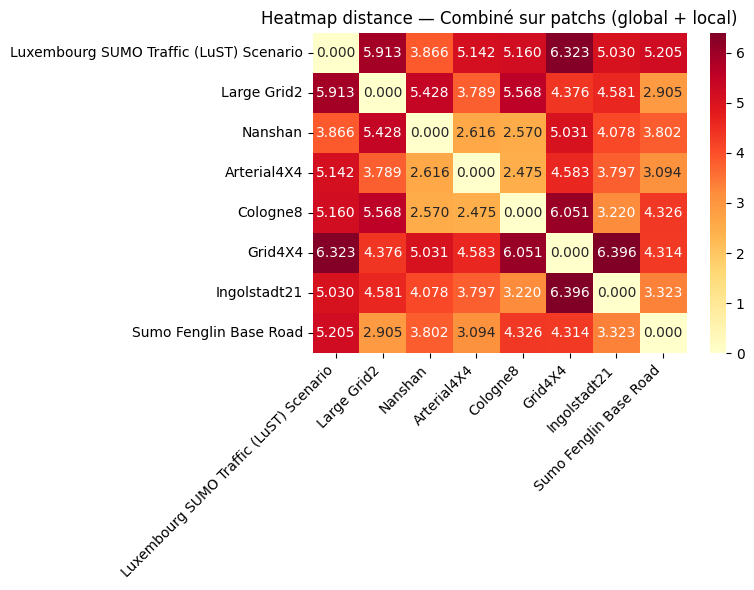


PCA (Combiné sur patchs (global + local)) — variance expliquée PC1+PC2: 67.5%


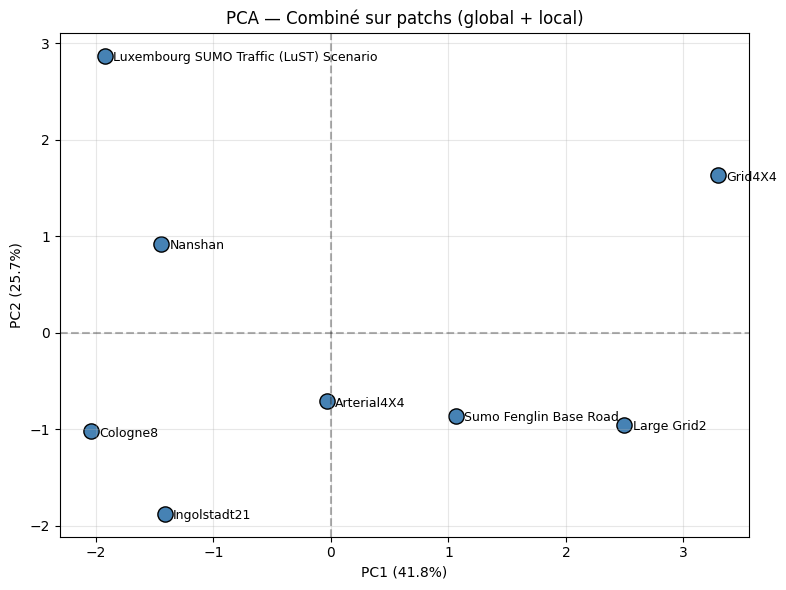

In [15]:
# --- SECTION 2.3 : Combiné sur patchs (local + global) — matrice des distances et PCA (avec valeurs) ---
df_patch_comb, df_patch_comb_norm, df_patch_comb_dist, df_patch_comb_pca = compute_and_plot(patch_sign_combined, 'Combiné sur patchs (global + local)', annotate=True)

#### Section 2.4 — Méthode minima composite sur patchs
Matrice composite unique basée sur min / max / mean / std des distances minimales sur patchs.


Matrice composite unique sur patchs (basée sur min / max / mean / std des minima) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,0.895,0.778,1.165,0.999,0.970,0.807,0.912
Large Grid2,0.895,0.000,1.402,1.037,1.603,0.754,0.878,0.731
Nanshan,0.778,1.402,0.000,0.590,0.806,1.215,0.577,0.441
Arterial4X4,1.165,1.037,0.590,0.000,0.743,0.865,0.599,0.632
Cologne8,0.999,1.603,0.806,0.743,0.000,1.138,0.597,0.638
Grid4X4,0.970,0.754,1.215,0.865,1.138,0.000,0.855,0.831
Ingolstadt21,0.807,0.878,0.577,0.599,0.597,0.855,0.000,0.576
Sumo Fenglin Base Road,0.912,0.731,0.441,0.632,0.638,0.831,0.576,0.000


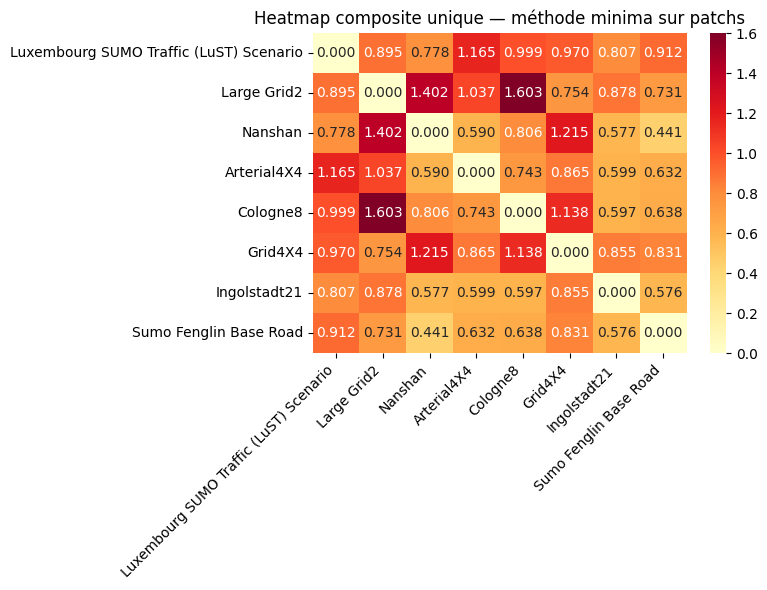


PCA (matrice composite unique sur patchs) — variance PC1+PC2: 67.1%


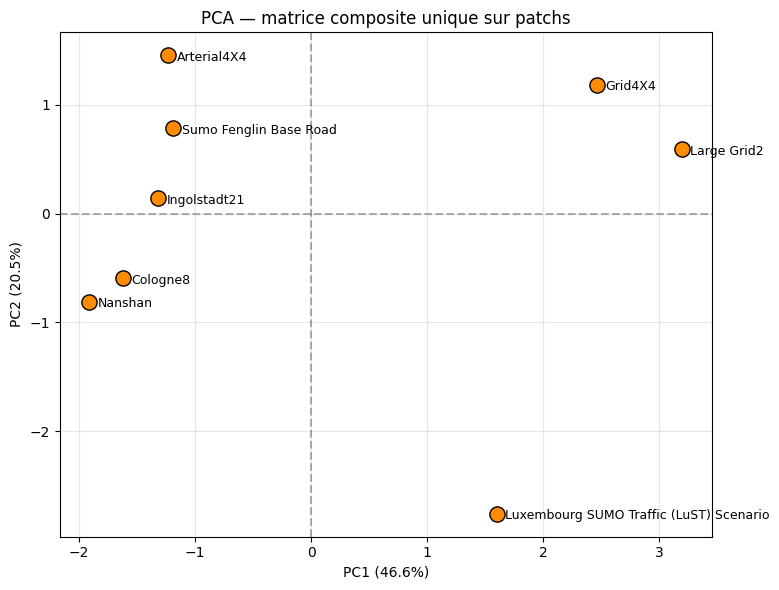

In [16]:
# --- SECTION 2.4 : Méthode minima sur patchs — matrice composite unique basée sur min / max / mean / std ---
# Même logique que la section 4, mais en remplaçant chaque carrefour par son patch.
all_patch_nodes_list = []
patch_net_keys = list(patch_nodes_per_network.keys())

for net in patch_net_keys:
    dfn = patch_nodes_per_network.get(net)
    if dfn is None or dfn.empty:
        continue
    dfn2 = dfn.reindex(columns=local_cols).fillna(0.0)
    dfn2.index = pd.MultiIndex.from_product([[net], dfn2.index], names=['reseau', 'patch'])
    all_patch_nodes_list.append(dfn2)

if not all_patch_nodes_list:
    print('Aucun patch disponible pour method minima sur patchs.')
else:
    df_all_patch_nodes = pd.concat(all_patch_nodes_list)
    scaler_patch_nodes = StandardScaler()
    X_patch_nodes = scaler_patch_nodes.fit_transform(df_all_patch_nodes.values)
    df_all_patch_nodes_norm = pd.DataFrame(X_patch_nodes, index=df_all_patch_nodes.index, columns=df_all_patch_nodes.columns)

    K = len(patch_net_keys)
    mat_minmin_p = np.zeros((K, K))
    mat_maxmin_p = np.zeros((K, K))
    mat_meanmin_p = np.zeros((K, K))
    mat_stdmin_p = np.zeros((K, K))

    for i, net_i in enumerate(patch_net_keys):
        idx_i = [idx for idx in df_all_patch_nodes_norm.index if idx[0] == net_i]
        Xi = df_all_patch_nodes_norm.loc[idx_i].values if idx_i else np.empty((0, df_all_patch_nodes_norm.shape[1]))

        for j, net_j in enumerate(patch_net_keys):
            idx_j = [idx for idx in df_all_patch_nodes_norm.index if idx[0] == net_j]
            Xj = df_all_patch_nodes_norm.loc[idx_j].values if idx_j else np.empty((0, df_all_patch_nodes_norm.shape[1]))

            if Xi.size == 0 or Xj.size == 0:
                mat_minmin_p[i, j] = np.nan
                mat_maxmin_p[i, j] = np.nan
                mat_meanmin_p[i, j] = np.nan
                mat_stdmin_p[i, j] = np.nan
                continue

            D = distance_matrix(Xi, Xj)
            mins = D.min(axis=1)

            mat_minmin_p[i, j] = float(mins.min())
            mat_maxmin_p[i, j] = float(mins.max())
            mat_meanmin_p[i, j] = float(mins.mean())
            mat_stdmin_p[i, j] = float(mins.std(ddof=0))

    df_minmin_p = pd.DataFrame(mat_minmin_p, index=patch_net_keys, columns=patch_net_keys)
    df_maxmin_p = pd.DataFrame(mat_maxmin_p, index=patch_net_keys, columns=patch_net_keys)
    df_meanmin_p = pd.DataFrame(mat_meanmin_p, index=patch_net_keys, columns=patch_net_keys)
    df_stdmin_p = pd.DataFrame(mat_stdmin_p, index=patch_net_keys, columns=patch_net_keys)

    feature_stack_p = np.stack([df_minmin_p.values, df_maxmin_p.values, df_meanmin_p.values, df_stdmin_p.values], axis=-1)
    for feature_idx in range(feature_stack_p.shape[-1]):
        feature = feature_stack_p[:, :, feature_idx].astype(float)
        mask = np.isfinite(feature)
        values = feature[mask].reshape(-1, 1)
        scaler_feat = StandardScaler()
        z_values = scaler_feat.fit_transform(values).ravel()
        z_feature = np.full(feature.shape, np.nan, dtype=float)
        z_feature[mask] = z_values
        feature_stack_p[:, :, feature_idx] = z_feature

    composite_p = np.sqrt(np.nanmean(np.square(feature_stack_p), axis=-1))
    composite_p = (composite_p + composite_p.T) / 2.0
    np.fill_diagonal(composite_p, 0.0)
    df_composite_p = pd.DataFrame(composite_p, index=patch_net_keys, columns=patch_net_keys)

    print('\nMatrice composite unique sur patchs (basée sur min / max / mean / std des minima) :')
    display(df_composite_p.round(3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_composite_p, cmap='YlOrRd', annot=True, fmt='.3f')
    plt.title('Heatmap composite unique — méthode minima sur patchs')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    scaler_comp_p = StandardScaler()
    X_comp_p = scaler_comp_p.fit_transform(df_composite_p.values)
    pca_comp_p = PCA(n_components=2)
    comps_comp_p = pca_comp_p.fit_transform(X_comp_p)
    df_pca_comp_p = pd.DataFrame(comps_comp_p, index=df_composite_p.index, columns=['PC1', 'PC2'])
    var_comp_p = pca_comp_p.explained_variance_ratio_

    print(f"\nPCA (matrice composite unique sur patchs) — variance PC1+PC2: {(var_comp_p[0] + var_comp_p[1]) * 100:.1f}%")
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca_comp_p['PC1'], df_pca_comp_p['PC2'], s=120, c='darkorange', edgecolors='black')
    for net in df_pca_comp_p.index:
        plt.annotate(net, (df_pca_comp_p.loc[net, 'PC1'], df_pca_comp_p.loc[net, 'PC2']), xytext=(6, -4), textcoords='offset points', fontsize=9)
    plt.xlabel(f"PC1 ({var_comp_p[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({var_comp_p[1] * 100:.1f}%)")
    plt.title('PCA — matrice composite unique sur patchs')
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Section 2.5 - Fusion des 3 distances
Fusion unique des matrices patchs locales, globales et minima après normalisation, puis heatmap et PCA sur la matrice combinée.


Matrice de consensus unique (patchs (locaux + globaux + minima)) :


,Luxembourg SUMO Traffic (LuST) Scenario,Large Grid2,Nanshan,Arterial4X4,Cologne8,Grid4X4,Ingolstadt21,Sumo Fenglin Base Road
Luxembourg SUMO Traffic (LuST) Scenario,0.000,0.546,0.355,0.485,0.470,0.585,0.455,0.470
Large Grid2,0.546,0.000,0.471,0.280,0.456,0.395,0.364,0.260
Nanshan,0.355,0.471,0.000,0.233,0.247,0.459,0.349,0.306
Arterial4X4,0.485,0.280,0.233,0.000,0.207,0.416,0.299,0.265
Cologne8,0.470,0.456,0.247,0.207,0.000,0.555,0.238,0.371
Grid4X4,0.585,0.395,0.459,0.416,0.555,0.000,0.570,0.351
Ingolstadt21,0.455,0.364,0.349,0.299,0.238,0.570,0.000,0.299
Sumo Fenglin Base Road,0.470,0.260,0.306,0.265,0.371,0.351,0.299,0.000


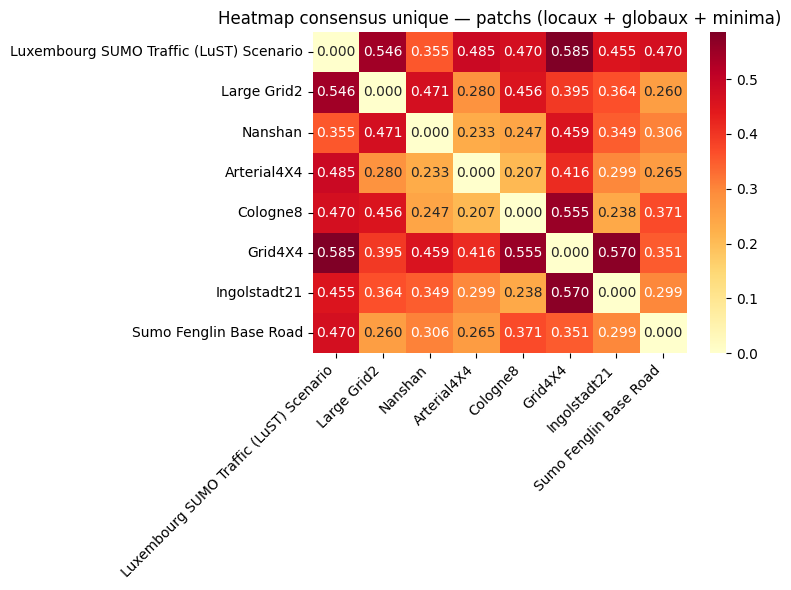


PCA (patchs (locaux + globaux + minima)) — variance PC1+PC2: 69.3%


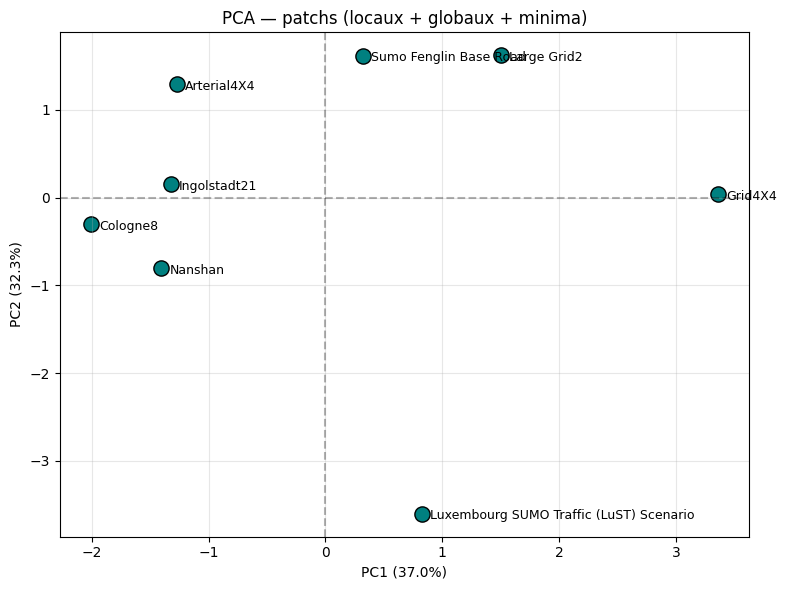

In [17]:
# --- SECTION 2.5 : Fusion des 3 distances ---
# Même principe que pour les carrefours seuls, mais appliqué aux patches.
df_consensus_patch_3dist, df_consensus_patch_3dist_pca = combine_three_distance_matrices(
    [df_patch_local_dist, df_patch_global_dist, df_composite_p],
    ['Locaux patchs', 'Globaux patchs', 'Minima patchs'],
    'patchs (locaux + globaux + minima)'
)

## Section 3 - comparaison section 1 vs section 2
Comparaison visuelle des résultats sans voisinage et avec voisinage, sous-section par sous-section.

In [18]:
# --- SECTION 3 : Comparaison section 1 vs section 2 ---


def _plot_matrix_comparison(left_dist, right_dist, left_pca, right_pca, left_title, right_title):
    heat_vmin = np.nanmin([left_dist.values, right_dist.values])
    heat_vmax = np.nanmax([left_dist.values, right_dist.values])

    x_values = np.concatenate([left_pca['PC1'].to_numpy(), right_pca['PC1'].to_numpy()])
    y_values = np.concatenate([left_pca['PC2'].to_numpy(), right_pca['PC2'].to_numpy()])
    x_margin = (x_values.max() - x_values.min()) * 0.12 if x_values.max() != x_values.min() else 1.0
    y_margin = (y_values.max() - y_values.min()) * 0.12 if y_values.max() != y_values.min() else 1.0

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    sns.heatmap(left_dist, ax=axes[0, 0], cmap='YlOrRd', annot=True, fmt='.3f', vmin=heat_vmin, vmax=heat_vmax)
    axes[0, 0].set_title(f"Heatmap - {left_title}")

    sns.heatmap(right_dist, ax=axes[0, 1], cmap='YlOrRd', annot=True, fmt='.3f', vmin=heat_vmin, vmax=heat_vmax)
    axes[0, 1].set_title(f"Heatmap - {right_title}")

    axes[1, 0].scatter(left_pca['PC1'], left_pca['PC2'], s=120, c='steelblue', edgecolors='black')
    for nom in left_pca.index:
        axes[1, 0].annotate(nom, (left_pca.loc[nom, 'PC1'], left_pca.loc[nom, 'PC2']), xytext=(6, -4), textcoords='offset points', fontsize=9)
    axes[1, 0].set_xlim(x_values.min() - x_margin, x_values.max() + x_margin)
    axes[1, 0].set_ylim(y_values.min() - y_margin, y_values.max() + y_margin)
    axes[1, 0].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[1, 0].axvline(0, color='k', linestyle='--', alpha=0.3)
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].set_title(f"PCA - {left_title}")
    axes[1, 0].set_xlabel('PC1')
    axes[1, 0].set_ylabel('PC2')

    axes[1, 1].scatter(right_pca['PC1'], right_pca['PC2'], s=120, c='darkorange', edgecolors='black')
    for nom in right_pca.index:
        axes[1, 1].annotate(nom, (right_pca.loc[nom, 'PC1'], right_pca.loc[nom, 'PC2']), xytext=(6, -4), textcoords='offset points', fontsize=9)
    axes[1, 1].set_xlim(x_values.min() - x_margin, x_values.max() + x_margin)
    axes[1, 1].set_ylim(y_values.min() - y_margin, y_values.max() + y_margin)
    axes[1, 1].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].axvline(0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].set_title(f"PCA - {right_title}")
    axes[1, 1].set_xlabel('PC1')
    axes[1, 1].set_ylabel('PC2')

    fig.suptitle(f"Comparaison - {left_title} vs {right_title}", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()


# Liste des comparaisons attendues (les matrices de consensus doivent être calculées
# respectivement dans la Section 1.5 (`df_consensus_3dist`, `df_consensus_3dist_pca`)
# et dans la Section 2.5 (`df_consensus_patch_3dist`, `df_consensus_patch_3dist_pca`).
comparisons_to_try = [
    ("df_local_dist", "df_patch_local_dist", "df_local_pca", "df_patch_local_pca", '1.1 Locaux', '2.1 Locaux sur patchs'),
    ("df_global_dist", "df_patch_global_dist", "df_global_pca", "df_patch_global_pca", '1.2 Globaux', '2.2 Globaux sur patchs'),
    ("df_comb_dist", "df_patch_comb_dist", "df_comb_pca", "df_patch_comb_pca", '1.3 Combiné', '2.3 Combiné sur patchs'),
    ("df_composite", "df_composite_p", "df_pca_comp", "df_pca_comp_p", '1.4 Méthode minima', '2.4 Méthode minima sur patchs'),
    ("df_consensus_3dist", "df_consensus_patch_3dist", "df_consensus_3dist_pca", "df_consensus_patch_3dist_pca", '1.5 Fusion 3 distances', '2.5 Fusion 3 distances sur patchs'),
]

# Vérification stricte : n'autorise pas la construction automatique des matrices de consensus ici.
missing_map = {}
for a, b, c, d, left_title, right_title in comparisons_to_try:
    missing = [name for name in (a, b, c, d) if name not in globals()]
    if missing:
        missing_map[(left_title, right_title)] = missing

if missing_map:
    msgs = []
    for (lt, rt), miss in missing_map.items():
        msgs.append(f"{lt} vs {rt}: variables manquantes -> {miss}")
    msgs.append("")
    msgs.append("NB: Ne pas exécuter de construction automatique ici. Pour obtenir les matrices manquantes:")
    msgs.append(" - Exécute la Section 1.5 pour générer `df_consensus_3dist` et `df_consensus_3dist_pca`.")
    msgs.append(" - Exécute la Section 2.5 pour générer `df_consensus_patch_3dist` et `df_consensus_patch_3dist_pca`.")
    raise RuntimeError("Comparaisons incomplètes:\n" + "\n".join(msgs))

# Si on arrive ici, toutes les variables nécessaires sont présentes — on construit la liste finale et on affiche.
comparisons_section_3 = [(globals()[a], globals()[b], globals()[c], globals()[d], left_title, right_title)
                         for a, b, c, d, left_title, right_title in comparisons_to_try]

for left_dist, right_dist, left_pca, right_pca, left_title, right_title in comparisons_section_3:
    _plot_matrix_comparison(left_dist, right_dist, left_pca, right_pca, left_title, right_title)

RuntimeError: Comparaisons incomplètes:
1.5 Fusion 3 distances vs 2.5 Fusion 3 distances sur patchs: variables manquantes -> ['df_consensus_3dist', 'df_consensus_3dist_pca']

NB: Ne pas exécuter de construction automatique ici. Pour obtenir les matrices manquantes:
 - Exécute la Section 1.5 pour générer `df_consensus_3dist` et `df_consensus_3dist_pca`.
 - Exécute la Section 2.5 pour générer `df_consensus_patch_3dist` et `df_consensus_patch_3dist_pca`.